<a href="https://colab.research.google.com/github/AishwaryaKalloli/andrejk/blob/main/makemore3_deepdive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [61]:
import random
random.seed(27)
g = torch.Generator().manual_seed(2147483647)

# Get data

In [62]:
!wget -q https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

In [63]:
words = open('names.txt', 'r').read().splitlines()

In [64]:
len(words), words[:3]

(32033, ['emma', 'olivia', 'ava'])

# Extract features

In [65]:
DOT = '.'
chars = [DOT] + sorted(list(set(''.join(words))))

In [66]:
stoi = {char: i for i, char in enumerate(chars)}
itos = {i : char for i, char in enumerate(chars)}
vocab_size = len(itos.items())

In [67]:
def sprint(**kwargs):
    for name, var in kwargs.items():
        print(f'{name}: {var}')

In [68]:
sprint(vocab_size=vocab_size, stoi=stoi, itos=itos)

vocab_size: 27
stoi: {'.': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}
itos: {0: '.', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z'}


# Dataset builder (X, Y)

In [69]:
def build_dataset(words, context_window_len):
    X, Y = [], []
    for word in words:
        context = [0] * context_window_len
        for char in word + DOT:
            X.append(context.copy())
            Y.append(stoi[char])
            context = context[1:] + [stoi[char]]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y


# NN builder (Linear, BatchNorm, Tanh)

In [70]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1, is_training=True):
        self.eps = eps
        self.momentum = momentum
        self.training = is_training

        # parameters trained with backprop
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # running mean and variance for the complete training set
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass
        if self.training:
            xmean = x.mean(dim=0, keepdim=True)
            xvar = x.var(dim=0, keepdim=True, unbiased=True)
        else:
            # for inference time
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # calculate the running mean during training
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

# Create dataset (train, test, validation)

In [71]:
random.shuffle(words)

context_window_len = 3
edge1 = int(0.8 * len(words))
edge2 = int(0.9 * len(words))

Xtrain, Ytrain = build_dataset(words[:edge1], context_window_len)
Xtest, Ytest = build_dataset(words[edge1:edge2], context_window_len)
Xval, Yval = build_dataset(words[edge2:], context_window_len)
sprint(Xtrain_shape=Xtrain.shape, Ytrain_shape=Ytrain.shape)

Xtrain_shape: torch.Size([182351, 3])
Ytrain_shape: torch.Size([182351])


# Create embeddings

In [72]:
embedding_dimensions = 10

# takes a letter and creates an n dimensional representation for it, initialised randomly learned by the network
C = torch.randn((vocab_size, embedding_dimensions), generator=g)

# Create rest of the network

In [73]:
num_hidden = 200
gain = 5/3
layers = [
    Linear((context_window_len * embedding_dimensions), num_hidden), #Tanh(),
    Linear(num_hidden, num_hidden), #Tanh(),
    Linear(num_hidden, num_hidden), #Tanh(),
    Linear(num_hidden, num_hidden), #Tanh(),
    Linear(num_hidden, num_hidden), #Tanh(),
    Linear(num_hidden, vocab_size)
    ]

# make last layer less confident and add tanh relevent gain for all other layers
with torch.no_grad():
    layers[-1].weight *= 0.1

    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= gain

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

172697


# Training the network

In [74]:
max_steps = 200000
batch_size = 32
lossi = []

In [75]:
debug_mode = True

In [76]:
# sample a batch from Xtrain, Ytrain
for i in range(max_steps):
    batch_indices = torch.randint(0, Xtrain.shape[0], (batch_size,), generator=g)
    Xbatch, Ybatch = Xtrain[batch_indices], Ytrain[batch_indices]
    # ---------------------------------------------------1. forward pass ------------------------------------------------------------------
    # get embedding for each
    emb = C[Xbatch] # batch_size x context_window_len x embedding_dimensions

    # concatnate the embeddings to form the input for NN
    x = emb.view(emb.shape[0], -1) # batch_size x (context_window_len x embedding_dimensions)

    # ---------------------------------------------1. forward pass --------------------------------------------------------------------------
    for layer in layers:
        x = layer(x)
        if debug_mode:
            layer.out.retain_grad()
    loss = F.cross_entropy(x, Ybatch)

    # ---------------------------------------------2. backprop --------------------------------------------------------------------------
    for p in parameters:
        p.grad = None  #remove previous grads to allow fresh calculation
    loss.backward()

    learning_rate = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -(learning_rate * p.grad)

    if i % (max_steps / 20) == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")
        break

      0/ 200000: 4.0874


layer 0 (    Linear): mean +0.08, std 1.65, saturated: 55.33%
layer 1 (    Linear): mean +0.06, std 2.69, saturated: 70.56%
layer 2 (    Linear): mean -0.11, std 4.52, saturated: 81.72%
layer 3 (    Linear): mean +0.02, std 7.53, saturated: 90.02%
layer 4 (    Linear): mean +0.27, std 12.46, saturated: 92.69%


Text(0.5, 1.0, 'activation distribution')

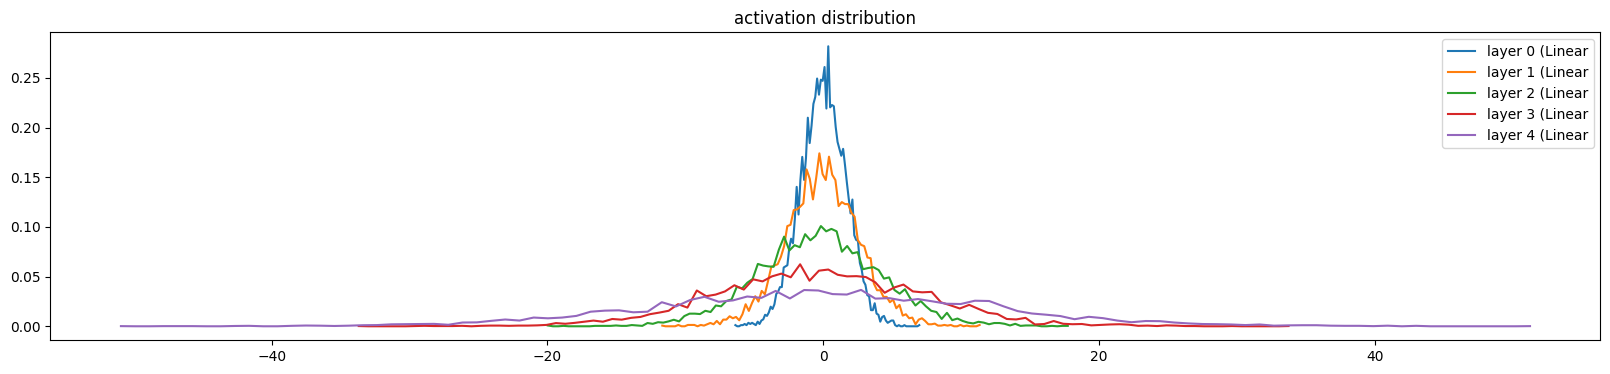

In [82]:
import matplotlib.pyplot as plt

# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Linear):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean().detach(), t.std().detach(), (t.abs() > 0.97).float().mean().detach()*100))
    hy, hx = torch.histogram(t.detach(), density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

In [83]:
5/3

1.6666666666666667

layer 0 (    Linear): mean +0.000028, std 1.750069e-03
layer 1 (    Linear): mean -0.000001, std 1.023303e-03
layer 2 (    Linear): mean -0.000008, std 6.309820e-04
layer 3 (    Linear): mean +0.000004, std 3.714183e-04
layer 4 (    Linear): mean -0.000005, std 2.260021e-04


Text(0.5, 1.0, 'gradient distribution')

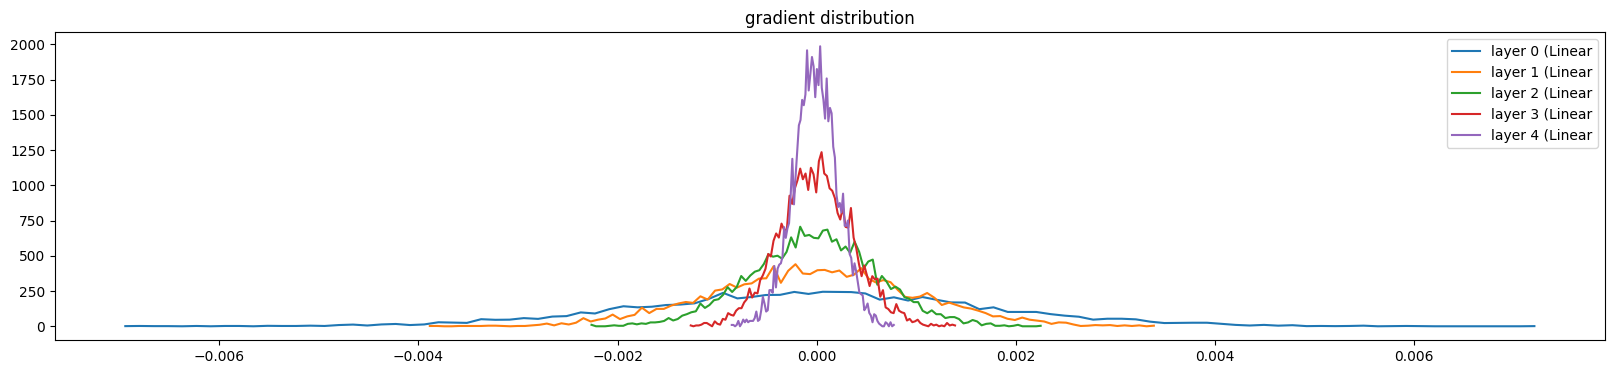

In [85]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Linear):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000967 | std 2.271424e-02 | grad:data ratio 2.271002e-02
weight  (30, 200) | mean +0.000073 | std 1.204991e-02 | grad:data ratio 3.879116e-02
weight (200, 200) | mean -0.000060 | std 1.161242e-02 | grad:data ratio 9.859498e-02
weight (200, 200) | mean -0.000015 | std 1.205814e-02 | grad:data ratio 1.024645e-01
weight (200, 200) | mean +0.000032 | std 1.193904e-02 | grad:data ratio 1.009153e-01
weight (200, 200) | mean -0.000065 | std 1.221307e-02 | grad:data ratio 1.038784e-01
weight  (200, 27) | mean -0.000000 | std 5.310493e-01 | grad:data ratio 1.000571e+01


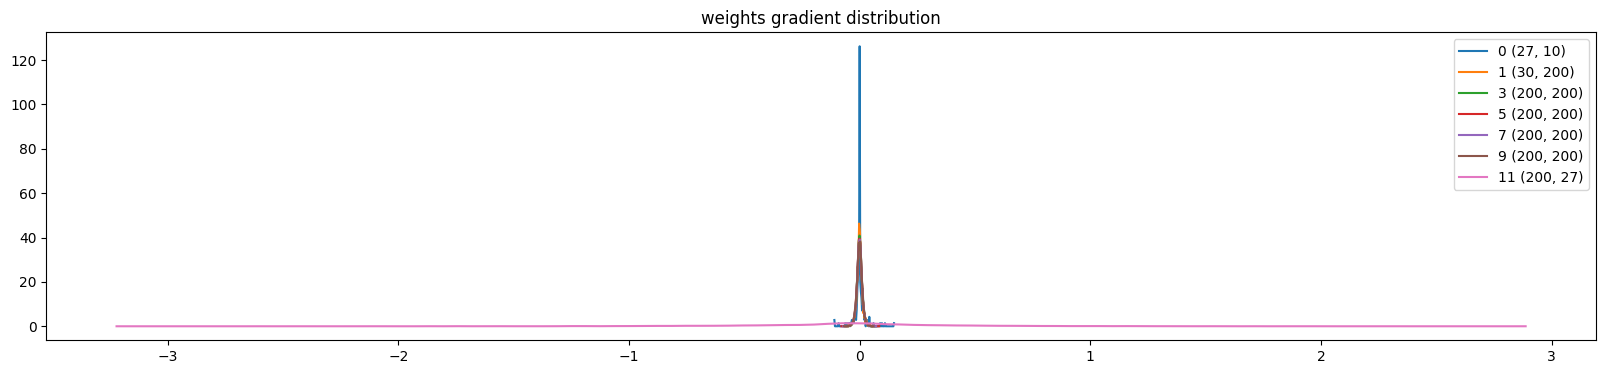

In [86]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std().detach() / p.std().detach()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

In [81]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


NameError: name 'ud' is not defined

<Figure size 2000x400 with 0 Axes>

so when we use batch norm with batch_norm_gain and batch_norm_bias we are asking the model to learn the actual output (through learning W1)
as well as,
how good a contender each feature is (of the 200 here) within the batch through the means of z-score - maybe a e i o u should have very low z-score(meaning they are used very often) when the training is complete



we can check it out of curiousity with slightly lower dimensional representations maybe and see if it is true